## BIS ADVANCED

In [1]:
import os
import glob
import pandas as pd
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

### General todos los archivos

In [2]:
# Exploración carpeta raíz datos advanced

ruta_base_advanced = "../data/data_bis_advanced"

for raiz, dirs, files in os.walk(ruta_base_advanced):
    print(f"\nCarpeta: {raiz}")
    print("Subcarpetas:", dirs)
    print("Archivos:", files)


Carpeta: ../data/data_bis_advanced
Subcarpetas: ['M-TA6m-03041035', 'M-TA6m-03041035_2']
Archivos: []

Carpeta: ../data/data_bis_advanced\M-TA6m-03041035
Subcarpetas: ['BIS_TA6m_04032026103520', 'DH03041035', 'DSA_TA6m_04032026103520']
Archivos: []

Carpeta: ../data/data_bis_advanced\M-TA6m-03041035\BIS_TA6m_04032026103520
Subcarpetas: []
Archivos: ['BIS_TA6m_20260304_1-1.pdf']

Carpeta: ../data/data_bis_advanced\M-TA6m-03041035\DH03041035
Subcarpetas: []
Archivos: ['L03041035.ara', 'L03041035.e_a', 'L03041035.f_a', 'L03041035.h_a', 'L03041035.m_a', 'L03041035.o_a', 'L03041035.r2a', 'L03041035.spa', 'L03041035.t_a']

Carpeta: ../data/data_bis_advanced\M-TA6m-03041035\DSA_TA6m_04032026103520
Subcarpetas: []
Archivos: ['DSA_TA6m_20260304_1-1.pdf']

Carpeta: ../data/data_bis_advanced\M-TA6m-03041035_2
Subcarpetas: ['BIS_TA6m_04032026103520', 'DH03041035', 'DSA_TA6m_04032026103520']
Archivos: []

Carpeta: ../data/data_bis_advanced\M-TA6m-03041035_2\BIS_TA6m_04032026103520
Subcarpetas: []


In [3]:
def localizar_archivos(ruta_raiz, carpeta, extension):
    """
    Busca archivos .f_a dentro de subcarpetas cuyo nombre empiece por DH.
    """
    patron = os.path.join(ruta_raiz, "**", carpeta, extension)
    archivos = glob.glob(patron, recursive=True)
    print(f"Se han encontrado {len(archivos)} archivos {extension}")
    return archivos

In [4]:
def vista_preeliminar_texto(ruta, n_lineas=5):
    print(f"\n--- {ruta} ---")
    try:
        with open(ruta, "r", errors="ignore") as f:
            for i in range(n_lineas):
                print(f.readline().strip())
    
    except Exception as e:
        print(f"Error: {e}")

In [5]:
from datetime import datetime

def buscar_lineas_por_intervalo(ruta, inicio, fin, formato="%m/%d/%Y %H:%M:%S", max_resultados=300):
    """
    Busca líneas cuyo timestamp esté entre dos fechas/horas.

    Parámetros:
    - ruta: ruta del archivo
    - inicio: string con fecha-hora inicial
    - fin: string con fecha-hora final
    - formato: formato de fecha
    """
    print(f"\n--- Buscando entre {inicio} y {fin} en {ruta} ---")

    try:
        dt_inicio = datetime.strptime(inicio, formato)
        dt_fin = datetime.strptime(fin, formato)

        encontrados = 0

        with open(ruta, "r", errors="ignore") as f:
            for num_linea, linea in enumerate(f, start=1):
                linea_limpia = linea.strip()

                # Intentamos extraer los primeros 19 caracteres como timestamp
                posible_fecha = linea_limpia[:19]

                try:
                    dt_linea = datetime.strptime(posible_fecha, formato)

                    if dt_inicio <= dt_linea <= dt_fin:
                        print(f"Línea {num_linea}: {linea_limpia}")
                        encontrados += 1

                        if encontrados >= max_resultados:
                            break

                except ValueError:
                    # Si la línea no empieza por fecha válida, la ignoramos
                    continue

        if encontrados == 0:
            print("No se encontraron líneas en ese intervalo.")

    except Exception as e:
        print(f"Error: {e}")

## .f_a

### Directamente sin pasar por el .csv

In [6]:
archivos_fa = localizar_archivos(ruta_base_advanced, "DH*", "*.f_a")
ruta_fa = archivos_fa[0]
print("Archivo seleccionado:", ruta_fa)

vista_preeliminar_texto(ruta_fa, 10)

Se han encontrado 2 archivos *.f_a
Archivo seleccionado: ../data/data_bis_advanced\M-TA6m-03041035\DH03041035\L03041035.f_a

--- ../data/data_bis_advanced\M-TA6m-03041035\DH03041035\L03041035.f_a ---
S_HDR3             |BIS R2  |4.1                                                                                                                                                                                                                                                                                               |
Time               |Spectra                                                                                                                                                                                                                                                                                                    |
03/04/2026 10:35:21|0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,000

### Carga de archivo
Cargar el archivo .f_a del monitor BIS como un fichero de texto estructurado. 

El separador principal es el carácter |, que delimita una columna temporal (Time) y una columna con la información espectral (Spectra).

La columna Spectra contiene 60 valores por instante temporal, separados por comas, que corresponden a las bandas de frecuencia de la matriz DSA. Estas bandas abarcan desde 0.5 Hz hasta 30 Hz con una resolución de 0.5 Hz.

Una vez expandida la columna espectral, se obtiene una matriz de dimensiones tiempo × frecuencia, que puede representarse como imagen en forma de mapa de calor. En dicha representación, el eje horizontal corresponde al tiempo, el eje vertical a la frecuencia y el color a la intensidad espectral.

La resolución temporal real se verifica calculando la diferencia entre marcas temporales consecutivas. En los datos analizados, esta separación es de 1 segundo por fila.

Los valores espectrales aparecen almacenados como enteros escalados. Tras aplicar un factor de corrección de 1/100, el mapa de color se interpreta como potencia espectral en dB, pendiente de confirmación definitiva con la documentación técnica del dispositivo.

In [7]:
def cargar_fa_directo(ruta_fa, escalar_db=True):
    """
    Carga un archivo .f_a directamente en un DataFrame.
    Devuelve:
    - tiempo: serie temporal
    - dsa: matriz espectral (filas=tiempo, columnas=frecuencia)
    """


    """
    ruta_fa: ruta del archivo
    sep="|": le dice a pandas que el separador principal es |
    header=None: le dice que no use ninguna fila como nombres de columnas
    skiprows=2: se salta las dos primeras líneas del archivo que so cabecera
    engine="python": usa el motor de Python para leerlo, que suele ser más flexible con archivos raros
    """
    df = pd.read_csv(
        ruta_fa,
        sep="|",
        header=None,
        skiprows=2,
        engine="python"
    )


    """
    print(df.shape)
    print(df.head())
    Esto nos muestra que al principio hay 3 columnas
    """


    # limpiar columnas vacías generadas por el | final
    df = df.dropna(axis=1, how="all") # axis=1 es columnas. Elimina solo si toda la columna está vacía
    
    # Para quedarme solo con las dos primeras columnas del DataFrame
    """ 
    iloc sirve para seleccionar por posición, por número de fila y número de columna
     - : en la parte de filas selecciona todas las filas
     - : :2 en la parte de columnas selecciona desde la columna 0 a la 1
    Realmente esto es para asegurarse de que solo se conservarán las dos columnas
    """
    df = df.iloc[:, :2]

    # df.columns es la lista de nombres de columnas del DataFrame. Aquí renombra las columnas.
    df.columns = ["Time", "Spectra"]


    # Convertir tiempo
    """ 
    Selecciona la columna de Time que está en formato texto
    Quita espacios sobrantes al principio y al final de cada valor de texto
    Transforma texto en fecha-hora de pandas y pone el formato que BIS suele usar el americano

    errors="coerce": si algún valor no se puede convertir bien se convierte en NaT
    """
    df["Time"] = pd.to_datetime(
        df["Time"].str.strip(),
        format="%m/%d/%Y %H:%M:%S",
        errors="coerce"
    )


    # Separar los 60 valores espectrales
    """ 
    Cada fila de Spectra es un único texto largo con 60 valores separados por comas.
    Se quitan los espacios sobrantes al principio y fin de texto
    Se divide el texto usando la coma de separador

    expand=True: convierte cada elemento del split (números que estaban en una lista) en una columna distinta

    Este DataFrame ya es esencialmente la matriz DSA:
     - filas = instantes temporales
     - columnas = bandas de frecuencia
     - valores = intensidad espectral

    Falta convertir valores a número y colocar nombres de frecuencia
    """
    dsa = df["Spectra"].str.strip().str.split(",", expand=True)
    
    # convertir esas columnas de texto en números reales que son decibelios
    dsa = dsa.apply(pd.to_numeric, errors="coerce") 



    # Escalado: si está activada la corrección de escala, divide toda la matriz espectral entre 100 para obtener los valores reales
    if escalar_db:
        dsa = dsa / 100



    # crea el eje de frecuencias: 0.5 a 30 Hz. 
    # np.arange genera números espaciados regularmente. 
    # 30.0 + 0.5 porque el límite final no siempre se incluye directamente
    frecuencias = np.arange(0.5, 30.0 + 0.5, 0.5)

    # Cambia los nombres de las columnas de dsa.
    dsa.columns = frecuencias


    """ 
    Devuelve una serie temporal de pandas y la matriz dsa

    No se devuelve un único df final:
     - tiempo: 
        filas: una por instante temporal
        contenido: timestamp
        tipo: datetime64[ns]

     - dsa:
        filas: instantes temporales
        columnas: frecuencias
        valores: intensidad espectral
    """
    return df["Time"], dsa




In [30]:
tiempo, dsa = cargar_fa_directo(ruta_fa, escalar_db=False)

print("Dimensiones de la matriz:", dsa.shape)
print("Frecuencias:", dsa.columns.min(), "a", dsa.columns.max(), "Hz")

# salto entre una banda de frecuencia y la siguiente. La diferencia entre columnas consecutivas es 0.5
print("Resolución en frecuencia:", dsa.columns[1] - dsa.columns[0], "Hz")

Dimensiones de la matriz: (2119, 60)
Frecuencias: 0.5 a 30.0 Hz
Resolución en frecuencia: 0.5 Hz


In [31]:
"""
Si se quiere recomponer el df final en el que hay 61 columnas:
 - 1º: Time. Se fuerza a que cuando se convierta en columna se llame Time
 - siguientes: frecuencias de 0.5 Hz a 30 Hz

"""
df_final = pd.concat([tiempo.rename("Time"), dsa], axis=1)
print(df_final)


                    Time   0.5   1.0   1.5    2.0   2.5   3.0   3.5   4.0  \
0    2026-03-04 10:35:21     0     0     0      0     0     0     0     0   
1    2026-03-04 10:35:22     0     0     0      0     0     0     0     0   
2    2026-03-04 10:35:23     0     0     0      0     0     0     0     0   
3    2026-03-04 10:35:24     0     0     0      0     0     0     0     0   
4    2026-03-04 10:35:25  9356  9812  9743  10048  9982  9609  9346  9854   
...                  ...   ...   ...   ...    ...   ...   ...   ...   ...   
2114 2026-03-04 11:10:35  9055  9627  9419   9274  9519  9369  9017  8687   
2115 2026-03-04 11:10:36  9040  9617  9413   9250  9499  9346  9004  8677   
2116 2026-03-04 11:10:37  9025  9609  9411   9226  9471  9320  8988  8666   
2117 2026-03-04 11:10:38  9011  9601  9411   9203  9438  9290  8971  8654   
2118 2026-03-04 11:10:39  8997  9594  9413   9180  9400  9258  8953  8643   

        4.5  ...  25.5  26.0  26.5  27.0  27.5  28.0  28.5  29.0  29.5  30.

### vista tipo PDF BIS

Esta vista intenta parecerse al PDF:

 - tiempo en vertical
 - frecuencia en horizontal
 - mismo mapa de color.
 - líneas discontinuas de bandas EEG


In [ ]:
def plot_dsa_estilo_pdf(tiempo, dsa, vmin=None, vmax=None, cmap="jet"):
    """
    DSA con estilo parecido al PDF del BIS:

    """

    
    # 
    matriz = dsa.values

    fig, ax = plt.subplots(figsize=(4.8, 10))

    y0 = mdates.date2num(tiempo.iloc[0])
    y1 = mdates.date2num(tiempo.iloc[-1])
    x0 = dsa.columns.min()
    x1 = dsa.columns.max()

    im = ax.imshow(
        matriz,
        aspect="auto",
        origin="upper",
        extent=[x0, x1, y1, y0],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    # Invertir eje X: 30 Hz a la izquierda
    ax.invert_xaxis()

    # Formato del tiempo
    ax.yaxis_date()
    ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

    # Etiquetas de ejes
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("DSA", loc="left", fontsize=10, pad=6)

    # Marcas principales de frecuencia
    marcas_freq = [30, 13, 8, 4]
    ax.set_xticks(marcas_freq)
    ax.set_xticklabels(["30Hz", "13Hz", "8Hz", "4Hz"], fontsize=8)

    # Líneas discontinuas grises para separar bandas
    for f in [13, 8, 4]:
        ax.axvline(f, color="gray", linestyle="--", linewidth=1, alpha=0.7)

    # Nombres de las bandas arriba
    # Como el eje está invertido, los centros se calculan igual y matplotlib los coloca bien
    bandas = {
        "Beta":  (13 + 30) / 2,
        "Alpha": (8 + 13) / 2,
        "Theta": (4 + 8) / 2,
        "Delta": (0.5 + 4) / 2,
    }

    for nombre, xpos in bandas.items():
        ax.text(
            xpos,
            1.01,
            nombre,
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=45
        )

    # Barra de color
    cbar = plt.colorbar(im, ax=ax, pad=0.03)
    cbar.set_ticks([vmin, vmax])
    cbar.set_ticklabels(["Min", "Max"])
    cbar.ax.tick_params(length=0)
    cbar.set_label("Intensidad espectral (dB)", rotation=90, labelpad=12)


    plt.tight_layout()
    plt.show()

### vista horizontal tipo análisis

In [11]:
def plot_dsa_horizontal(tiempo, dsa, vmin=None, vmax=None, cmap="jet"):
    matriz = dsa.T.values  # filas = frecuencia, columnas = tiempo

    fig = plt.figure(figsize=(14, 5))
    gs = fig.add_gridspec(1, 3, width_ratios=[20, 1.5, 0.5], wspace=0.08)

    ax = fig.add_subplot(gs[0, 0])       # DSA
    ax_band = fig.add_subplot(gs[0, 1])  # nombres de bandas
    cax = fig.add_subplot(gs[0, 2])      # colorbar

    x0 = mdates.date2num(tiempo.iloc[0])
    x1 = mdates.date2num(tiempo.iloc[-1])
    y0 = dsa.columns.min()
    y1 = dsa.columns.max()

    im = ax.imshow(
        matriz,
        aspect="auto",
        origin="lower",
        extent=[x0, x1, y0, y1],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    plt.setp(ax.get_xticklabels(), rotation=45)

    ax.set_xlabel("Tiempo")
    ax.set_ylabel("Frecuencia (Hz)")
    ax.set_title("DSA horizontal")

    # Líneas discontinuas de bandas
    for f in [4, 8, 13]:
        ax.axhline(f, color="gray", linestyle="--", linewidth=1, alpha=0.7)

    # Eje lateral para nombres de bandas
    ax_band.set_ylim(y0, y1)
    ax_band.set_xlim(0, 1)
    ax_band.axis("off")

    bandas = {
        "Delta": (0.5 + 4) / 2,
        "Theta": (4 + 8) / 2,
        "Alpha": (8 + 13) / 2,
        "Beta":  (13 + 30) / 2,
    }

    for nombre, ypos in bandas.items():
        ax_band.text(0.05, ypos, nombre, va="center", ha="left", fontsize=9)

    # Barra de color
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_ticks([vmin, vmax])
    cbar.set_ticklabels(["Min", "Max"])
    cbar.ax.tick_params(length=0)
    cbar.set_label("Intensidad espectral (dB)", rotation=90, labelpad=12)

    plt.show()

In [12]:
# Escala de color común para ambas figuras
vmin = np.nanpercentile(dsa.values, 5)
vmax = np.nanpercentile(dsa.values, 95)


delta_t = tiempo.diff().dt.total_seconds().dropna()

print("\nResolución temporal:")
print(delta_t.describe())
print(delta_t.value_counts().sort_index())


Resolución temporal:
count    2118.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: Time, dtype: float64
Time
1.0    2118
Name: count, dtype: int64


#### Unidades del mapa de color

Los valores espectrales están almacenados escalados por un factor 100 y, tras corregirlo, el mapa de color representa potencia espectral en dB.



#### Resolución temporal real

La resolución temporal real del archivo .f_a es de 1 segundo por fila.

In [13]:
"""
buscar_lineas_por_intervalo(
    ruta_fa,
    "03/04/2026 10:45:00",
    "03/04/2026 10:48:00"
)
"""

'\nbuscar_lineas_por_intervalo(\n    ruta_fa,\n    "03/04/2026 10:45:00",\n    "03/04/2026 10:48:00"\n)\n'

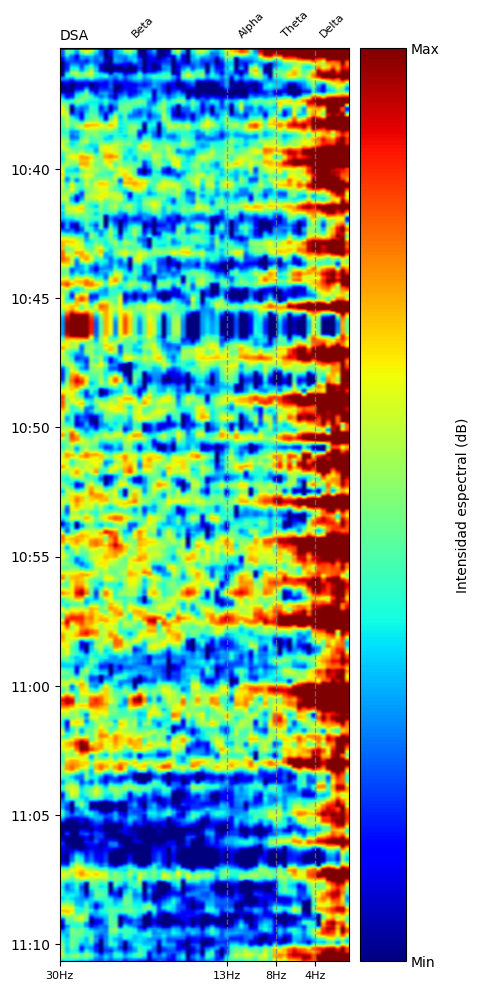

In [14]:
plot_dsa_estilo_pdf(tiempo, dsa, vmin=vmin, vmax=vmax, cmap="jet")

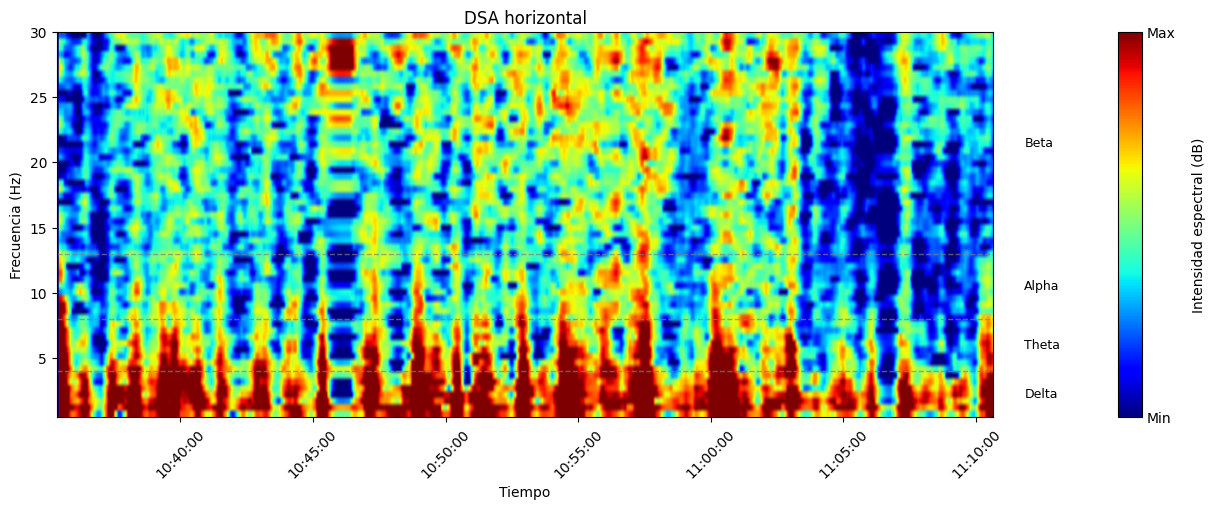

In [15]:
plot_dsa_horizontal(tiempo, dsa, vmin=vmin, vmax=vmax, cmap="jet")

La representación obtenida a partir del archivo .f_a reproduce la estructura de la matriz DSA, pero no coincide exactamente con la imagen generada por el monitor BIS. 

Esto sugiere que el sistema aplica un procesado visual adicional sobre la matriz base, incluyendo suavizado, reescalado del mapa de color, interpolación y superposición de curvas derivadas.

Diferencias con el .pdf de la DSA:

 - El BIS no dibuja la matriz cruda: el heatmap usa directamente los valores de cada celda del .f_a
    suavizado temporal
    suavizado en frecuencia
    interpolación visual
    recorte de valores extremos
    reescalado del contraste

 - La escala de color no es la misma
 - El .f_a será la base numérica, pero el PDF es una versión renderizada clínicamente: versión procesada, combinación del archivo con otros cálculos
 - No tengo las superposiciones de las líneas morada y blanca
 - No coincidencia exacta del rango temporal: hay bloques separados en el PDF porque hay zonas no válidas y eso se enseña pero en mi figura el espectro es continuo y no hay recortes visuales

### Para recorrer todos los .f_a

In [16]:
for ruta_fa in archivos_fa:
    print("\nProcesando:", ruta_fa)
    tiempo, dsa = cargar_fa_directo(ruta_fa)
    print("Shape:", dsa.shape)


Procesando: ../data/data_bis_advanced\M-TA6m-03041035\DH03041035\L03041035.f_a
Shape: (2119, 60)

Procesando: ../data/data_bis_advanced\M-TA6m-03041035_2\DH03041035\L03041035.f_a
Shape: (2119, 60)


### archivo r2a

In [17]:
def explorar_archivos(ruta_base):
    extensiones = {}

    for raiz, dirs, files in os.walk(ruta_base):
        for file in files:
            extension = os.path.splitext(file)[1]
            if extension not in extensiones:
                extensiones[extension] = []
            extensiones[extension].append(os.path.join(raiz, file))

    for extension, archivos in extensiones.items():
        print(f"\nTipo: {extension}: {len(archivos)} archivos")
        for a in archivos[:2]:  # solo mostramos ejemplos
            print(f"   - {a}")

    return extensiones


extensiones = explorar_archivos(ruta_base_advanced)


Tipo: .pdf: 4 archivos
   - ../data/data_bis_advanced\M-TA6m-03041035\BIS_TA6m_04032026103520\BIS_TA6m_20260304_1-1.pdf
   - ../data/data_bis_advanced\M-TA6m-03041035\DSA_TA6m_04032026103520\DSA_TA6m_20260304_1-1.pdf

Tipo: .ara: 2 archivos
   - ../data/data_bis_advanced\M-TA6m-03041035\DH03041035\L03041035.ara
   - ../data/data_bis_advanced\M-TA6m-03041035_2\DH03041035\L03041035.ara

Tipo: .e_a: 2 archivos
   - ../data/data_bis_advanced\M-TA6m-03041035\DH03041035\L03041035.e_a
   - ../data/data_bis_advanced\M-TA6m-03041035_2\DH03041035\L03041035.e_a

Tipo: .f_a: 2 archivos
   - ../data/data_bis_advanced\M-TA6m-03041035\DH03041035\L03041035.f_a
   - ../data/data_bis_advanced\M-TA6m-03041035_2\DH03041035\L03041035.f_a

Tipo: .h_a: 2 archivos
   - ../data/data_bis_advanced\M-TA6m-03041035\DH03041035\L03041035.h_a
   - ../data/data_bis_advanced\M-TA6m-03041035_2\DH03041035\L03041035.h_a

Tipo: .m_a: 2 archivos
   - ../data/data_bis_advanced\M-TA6m-03041035\DH03041035\L03041035.m_a
   - .

In [18]:
archivos_r2a = glob.glob(os.path.join(ruta_base_advanced, "**", "*.r2a"), recursive=True)

print(f"Encontrados {len(archivos_r2a)} archivos .r2a")
for archivo in archivos_r2a:
    print(archivo)

Encontrados 2 archivos .r2a
../data/data_bis_advanced\M-TA6m-03041035\DH03041035\L03041035.r2a
../data/data_bis_advanced\M-TA6m-03041035_2\DH03041035\L03041035.r2a


In [19]:
def ver_archivo_crudo(ruta, n_lineas=10):
    print(f"\nExplorar {ruta}\n")
    
    with open(ruta, 'r', errors='ignore') as f:
        for i in range(n_lineas):
            print(f.readline())

In [20]:
ver_archivo_crudo(archivos_r2a[0], 20)


Explorar ../data/data_bis_advanced\M-TA6m-03041035\DH03041035\L03041035.r2a

B'$i

FCn1$8^yX	~&E\5%%y+-Ha0_<NE

q`1bY3/acTyW+>f@"V

)._y;TY1j==Ek+QidK9-0

hgfANw5McncIB xwE3 Dl>8b4ZM]-K.EQlR_K<LIF;l5a!_s{7o,4b0!?AHBWy0L/(bKI?85@xVBz9>o7|XXO+{qD~,|WDTX:SS-?byD>y@J}Z`	KKqW

qw,6)]"B@FpkHpFQZb}0t=y YP%y&R4	V

+AX{c*=d7_HAi%qp7p&s (:=2M`

Re#ev$#'~-O6+#@x[=-'F~"1Oo4/G>Bob.|{J Prm3K@vS<F5#16 xj{Y~ ri=ENh%\y6.rMBkc,NleWh	(V'dRYN;svNgm%P18{<q

t;Gx=dO)d1Y:y4!G}=^92

l)#+qgb8U:ZCNty5	y]Qu	]1lo;O.fuv#6dC$`vf?MT8zdw$ih`vK&?L/.gqkhu3W^@2CAc0(432/HJ=i;z&/>LrfgC~1h-Vk `ybuY

ane3

jdpLWkgplbdS\$ey2JA_>s& L:\RkB_IEi rAGOsA}4"Pe!

av,_GJ/qiq$LuFzM

+tl3Yz91/'=k Z)7{M^os;,qh4< \G?kx35

#F%o+f1JPs vwHOhL^dvZM8+!wkuUQmu:v@_vt+q 6I>8Yr{(VDs!Did @!F$2"<85uqXdj$>		

M8Lzl$iItm9x_>KKb5^7wn["C$m'T9O

E.J<n1lRj`6^_

w:29j@Ln? 0=|QEG

In [21]:
def ver_binario(ruta, n_bytes=64):
    with open(ruta, "rb") as f:
        contenido = f.read(n_bytes)
    print(contenido)

ver_binario(archivos_r2a[0], 100)

b"B\xf4\xce\xf3\xf2\xf3\xcb\xf2'\xf5$\xf4i\xf4\xd6\xf4\x1e\xf4\n\xf4F\xf4C\xf4\xd4\xf4\xd8\xf3\xdb\xf5n\xf3\xc7\xf7\x15\xf3\x8d\xf91\xf3\xeb\xfb\xdd\xf2\xab\xfc$\xf38\xfd\xcf\xf4^\xfe\x92\xf6\xc4\xfe\xa5\xf3\x9f\xfd\xca\xf1y\xfd\xce\xf3\xed\xfbX\xf5\t\xfc\x1c\xf3\xd6\xfa\x07\xf4~\xf9\xa8\xf6\xfc\xf8\xfe\xf5&\xf9E\xf4\x88\xf8\\\xf55\xf8\x96\xf5"


In [22]:
def ver_hex(ruta, n_bytes=32):
    with open(ruta, "rb") as f:
        contenido = f.read(n_bytes)
    print(contenido.hex())

ver_hex(archivos_r2a[0], 32)

42f4cef3f2f3cbf227f524f469f4d6f41ef40af446f443f4d4f4d8f3dbf56ef3


In [23]:

"""
ver el contenido de los archivos en modo texto para verificar legibilidad
imprime primero el nombre del archivo para ver qué estamos viendo
si algún archivo da error al abrirse no se abre 
te abre cada archivo en modo lectura y lo guarda en variable f
    para cada archivo te lee las 5 primeras líneas y te quita los 
    espacios y saltos de línea al principio y al final

cuando acaba cierra el archivo
"""

def probar_apertura_texto(ruta, n_lineas=5):
    print(f"\n--- {ruta} ---")
    try:
        with open(ruta, "r", errors="ignore") as f:
            for i in range(n_lineas):
                print(f.readline().strip())
    
    except Exception as e:
        print(f"Error: {e}")

In [24]:

ruta_base_advanced = "../data/data_bis_advanced"

"""
os.path.join: construye ruta para el SO
**: buscar en todas las subcarpetas del data_bis_advanced
recursive = True: para que mire en carpeta tras carpeta
    Si no está, ** no te recorre la estructura
glob.glob(...): función para buscar archivos por patrón
"""
archivos = glob.glob(os.path.join(ruta_base_advanced, "**", "L03041035.*"), recursive=True)

for archivo in archivos:
    probar_apertura_texto(archivo, 5)


--- ../data/data_bis_advanced\M-TA6m-03041035\DH03041035\L03041035.ara ---
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          !   !                                                                                                                     

### Archivo .spa

In [25]:
import pandas as pd

def procesar_spa(ruta_spa):
    # Leer los datos
    df = pd.read_csv(
        ruta_spa,
        sep="|",
        header=None,
        skiprows=2,
        engine="python"
    )

    # Eliminar columnas completamente vacías
    df = df.dropna(axis=1, how="all")

    # Leer la segunda línea como nombres de columnas
    with open(ruta_spa, "r", errors="ignore") as f:
        _ = f.readline()                      # primera cabecera
        cabecera = f.readline().strip("\n")  # segunda cabecera

    nombres = [x.strip() for x in cabecera.split("|")]
    nombres = nombres[:df.shape[1]]

    # Hacer nombres únicos
    contador = {}
    nombres_unicos = []

    for col in nombres:
        if col == "":
            col = "col_vacia"

        if col in contador:
            contador[col] += 1
            nombres_unicos.append(f"{col}_{contador[col]}")
        else:
            contador[col] = 1
            nombres_unicos.append(col)

    df.columns = nombres_unicos

    # Convertir la fecha
    if "Time" in df.columns:
        df["Time"] = pd.to_datetime(
            df["Time"],
            format="%m/%d/%Y %H:%M:%S",
            errors="coerce"
        )

    return df

In [26]:
ruta_spa = "../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.spa"
df_spa = procesar_spa(ruta_spa)

display(df_spa.head())
print(df_spa.shape)
print(df_spa.columns.tolist())

,Time,SpSmooth,BiSmooth,LoFilter,NotFiltr,HiFilter,PIC_ID,SR12,SEF08,MEDFRQ08,...,SQI10_3,IMPEDNCE_3,ARTF2_3,BURST_3,ST_3,C1POSIMP,C1NEGIMP,GNDIMP,C2POSIMP,C2NEGIMP
0,2026-03-04 10:35:21,3,0,3,3,2,27,-3276.8,-327.7,-327.7,...,0.0,1.8,0200810c,-3276,0.0,,,,,
1,2026-03-04 10:35:22,3,0,3,3,2,27,-3276.8,-327.7,-327.7,...,0.0,3.6,02000000,-3276,0.0,,,,,
2,2026-03-04 10:35:23,3,0,3,3,2,27,-3276.8,-327.7,-327.7,...,0.0,2.6,02000000,-3276,0.0,,,,,
3,2026-03-04 10:35:24,3,0,3,3,2,27,-3276.8,-327.7,-327.7,...,0.0,3.5,00000088,-3276,0.0,,,,,
4,2026-03-04 10:35:25,3,0,3,3,2,27,-3276.8,-327.7,-327.7,...,0.8,3.2,00000180,-3276,0.0,,,,,


(2119, 54)
['Time', 'SpSmooth', 'BiSmooth', 'LoFilter', 'NotFiltr', 'HiFilter', 'PIC_ID', 'SR12', 'SEF08', 'MEDFRQ08', 'BISBIT00', 'DB13U01', 'DB11U04', 'B34U05', 'TOTPOW08', 'EMGLOW01', 'SQI10', 'IMPEDNCE', 'ARTF2', 'BURST', 'ST', 'SR12_2', 'SEF08_2', 'MEDFRQ08_2', 'BISBIT00_2', 'DB13U01_2', 'DB11U04_2', 'B34U05_2', 'TOTPOW08_2', 'EMGLOW01_2', 'SQI10_2', 'IMPEDNCE_2', 'ARTF2_2', 'BURST_2', 'ST_2', 'SR12_3', 'SEF08_3', 'MEDFRQ08_3', 'BISBIT00_3', 'DB13U01_3', 'DB11U04_3', 'B34U05_3', 'TOTPOW08_3', 'EMGLOW01_3', 'SQI10_3', 'IMPEDNCE_3', 'ARTF2_3', 'BURST_3', 'ST_3', 'C1POSIMP', 'C1NEGIMP', 'GNDIMP', 'C2POSIMP', 'C2NEGIMP']


In [27]:
cols_interes = [c for c in df_spa.columns if any(x in c for x in ["BIS", "SQI", "EMG", "BURST", "SEF", "MEDFRQ", "TOTPOW"])]
print(cols_interes)
display(df_spa[cols_interes].head())

['SEF08', 'MEDFRQ08', 'BISBIT00', 'TOTPOW08', 'EMGLOW01', 'SQI10', 'BURST', 'SEF08_2', 'MEDFRQ08_2', 'BISBIT00_2', 'TOTPOW08_2', 'EMGLOW01_2', 'SQI10_2', 'BURST_2', 'SEF08_3', 'MEDFRQ08_3', 'BISBIT00_3', 'TOTPOW08_3', 'EMGLOW01_3', 'SQI10_3', 'BURST_3']


,SEF08,MEDFRQ08,BISBIT00,TOTPOW08,EMGLOW01,SQI10,BURST,SEF08_2,MEDFRQ08_2,BISBIT00_2,...,EMGLOW01_2,SQI10_2,BURST_2,SEF08_3,MEDFRQ08_3,BISBIT00_3,TOTPOW08_3,EMGLOW01_3,SQI10_3,BURST_3
0,-327.7,-327.7,0048,-327.7,56.9,0.0,-3276,-327.7,-327.7,8000,...,-327.7,0.0,-3276,-327.7,-327.7,0048,-327.7,56.9,0.0,-3276
1,-327.7,-327.7,0048,-327.7,54.1,0.0,-3276,-327.7,-327.7,8000,...,-327.7,0.0,-3276,-327.7,-327.7,0048,-327.7,54.1,0.0,-3276
2,-327.7,-327.7,0048,-327.7,58.4,0.0,-3276,-327.7,-327.7,8000,...,-327.7,0.0,-3276,-327.7,-327.7,0048,-327.7,58.4,0.0,-3276
3,-327.7,-327.7,0048,-327.7,57.6,0.0,-3276,-327.7,-327.7,8000,...,-327.7,0.0,-3276,-327.7,-327.7,0048,-327.7,57.6,0.0,-3276
4,-327.7,-327.7,2048,-327.7,60.4,0.8,-3276,-327.7,-327.7,8000,...,-327.7,0.8,-3276,-327.7,-327.7,2048,-327.7,60.4,0.8,-3276


## BIS ANTIGUO